In [1]:
import os, sys, pickle, copy
import numpy as np
import matplotlib.pyplot as plt
import corner
import matplotlib.lines as mlines

In [2]:
def load_chain(path, param_names, mock_mean=[], mock_std=[], num_samples=[]):
    if os.path.exists(path):
        with open(path, 'rb') as handle:
            chain = pickle.load(handle)
        np.random.seed(42)
        for name, mean, std in zip(param_names, mock_mean, mock_std):
            if name not in chain:
                print(f"Warning: Key '{name}' not found in {path}. Generating mock data for this key.")
                chain[name] = np.random.normal(mean, std, len(next(iter(chain.values()))))
        return chain
    else:
        print(f"Warning: {path} not found. Generating mock data for visualization.")
        np.random.seed(42)
        chain = {}
        for name, mean, std in zip(param_names, mock_mean, mock_std):
            chain[name] = np.random.normal(mean, std, num_samples)
        return chain

param_names = [r'$\theta_{\rm E}$', r'$\gamma$', r'$q_{\rm m}$', r'$\phi_{\rm m}$']#, r'$\gamma_{\rm ext}$', r'$\phi_{\rm ext}$'

flat_chains = load_chain(
    's4_models/flat_chains.pickle',
    param_names,
)
flat_chains

{'$\\theta_{\\rm E}$': array([12.86461071, 12.86461071, 12.86461071, ..., 12.85688184,
        12.85688184, 12.85688184], shape=(63000,)),
 '$\\gamma$': array([1.42974757, 1.42974757, 1.42974757, ..., 1.43048853, 1.43048853,
        1.43048853], shape=(63000,)),
 '$q_{\\rm m}$': array([0.82380808, 0.82380808, 0.82380808, ..., 0.82825957, 0.82825957,
        0.82825957], shape=(63000,)),
 '$\\phi_{\\rm m}$': array([-81.59419543, -81.59419543, -81.59419543, ..., -81.83332489,
        -81.83332489, -81.83332489], shape=(63000,)),
 '$\\gamma_{\\rm ext}$': array([0.01907674, 0.01907674, 0.01907674, ..., 0.0202654 , 0.0202654 ,
        0.0202654 ], shape=(63000,)),
 '$\\phi_{\\rm ext}$': array([0.75816004, 0.75816004, 0.75816004, ..., 0.71380261, 0.71380261,
        0.71380261], shape=(63000,))}

In [3]:
shapelets_chains = load_chain(
    's4_models/flatshapelets_chains.pickle',
    param_names,
)
shapelets_chains

{'$\\theta_{\\rm E}$': array([12.82670375, 12.82826485, 12.82826485, ..., 12.81341837,
        12.81379921, 12.81782301], shape=(62700,)),
 '$\\gamma$': array([1.42237521, 1.42321526, 1.42321526, ..., 1.41347662, 1.41318436,
        1.41473762], shape=(62700,)),
 '$q_{\\rm m}$': array([0.83485085, 0.83451355, 0.83451355, ..., 0.83406577, 0.83361165,
        0.83425645], shape=(62700,)),
 '$\\phi_{\\rm m}$': array([-81.08422251, -81.06797253, -81.06797253, ..., -81.11580041,
        -81.12363894, -81.19958938], shape=(62700,)),
 '$\\gamma_{\\rm ext}$': array([0.01874076, 0.01880144, 0.01880144, ..., 0.01714037, 0.01702086,
        0.01750743], shape=(62700,)),
 '$\\phi_{\\rm ext}$': array([0.65554984, 0.6551734 , 0.6551734 , ..., 0.70526659, 0.71250573,
        0.70200343], shape=(62700,))}

In [4]:
iful_chains = load_chain(
    's4_models/iful_chains.pickle',
    param_names,
)
iful_chains

{'$\\theta_{\\rm E}$': array([12.84686689, 12.84817997, 12.84788627, ..., 12.84693522,
        12.84706588, 12.84586229], shape=(984312,)),
 '$\\gamma$': array([1.44271969, 1.44320303, 1.4430784 , ..., 1.44239854, 1.44258811,
        1.44177796], shape=(984312,)),
 '$q_{\\rm m}$': array([0.84064703, 0.84042529, 0.84044729, ..., 0.84056618, 0.8405998 ,
        0.84078604], shape=(984312,)),
 '$\\phi_{\\rm m}$': array([-81.23534291, -81.19458469, -81.2171171 , ..., -81.23174933,
        -81.23001212, -81.25396346], shape=(984312,)),
 '$\\gamma_{\\rm ext}$': array([0.02468345, 0.02466078, 0.02467691, ..., 0.02458217, 0.02462706,
        0.02453724], shape=(984312,)),
 '$\\phi_{\\rm ext}$': array([0.55257859, 0.55150097, 0.55237221, ..., 0.55384991, 0.55296769,
        0.55466806], shape=(984312,))}

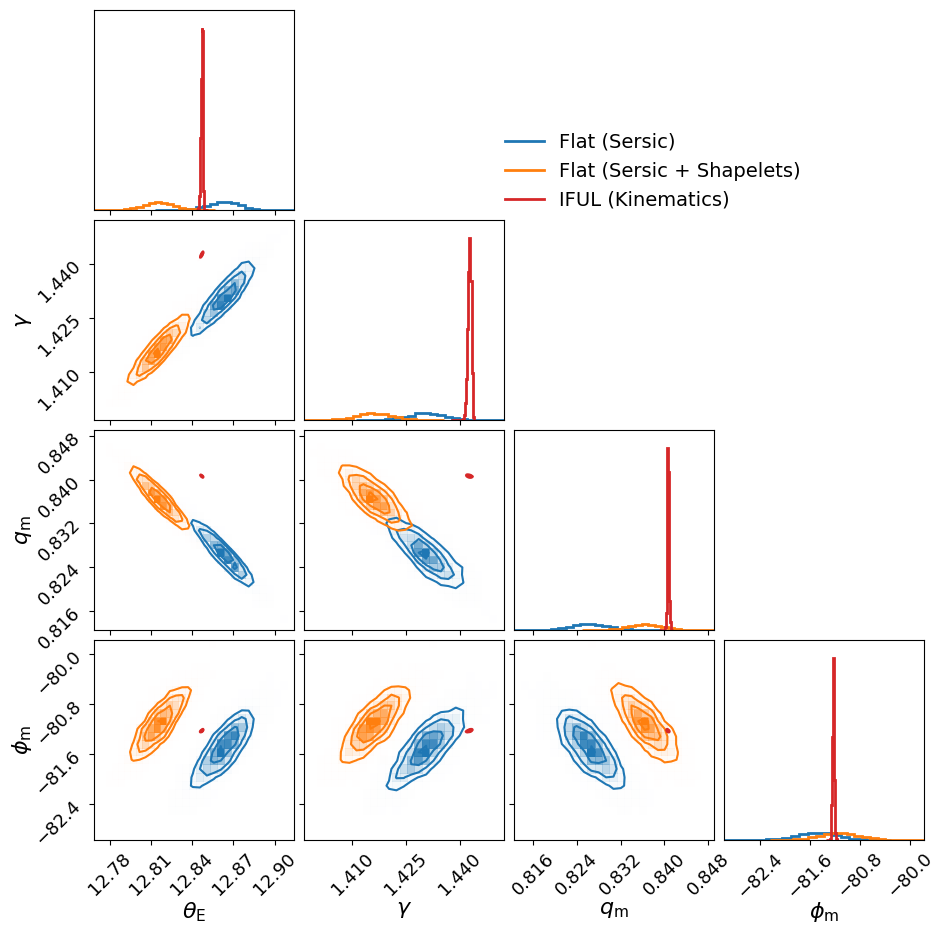

In [5]:
# Extract sample arrays for each model
flat_samples = np.column_stack([flat_chains[p] for p in param_names])
shapelets_samples = np.column_stack([shapelets_chains[p] for p in param_names])
iful_samples = np.column_stack([iful_chains[p] for p in param_names])

# Create the figure with the first dataset (flat_chains)
fig = corner.corner(
    flat_samples,
    labels=param_names,
    color="#1f77b4",          # Sleek Blue
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    show_titles=False,
    hist_kwargs={"linewidth": 2},
    label_kwargs={"fontsize": 16}
)

# Overlay the second dataset (shapelets_chains)
corner.corner(
    shapelets_samples,
    fig=fig,
    color="#ff7f0e",          # Vibrant Orange
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    show_titles=False,
    hist_kwargs={"linewidth": 2}
)

# Overlay the third dataset (iful_chains)
corner.corner(
    iful_samples,
    fig=fig,
    color="#d62728",          # Crimson Red
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    show_titles=False,
    hist_kwargs={"linewidth": 2}
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=13)

# Add custom legend proxy artists
legend_labels = ["Flat (Sersic)", "Flat (Sersic + Shapelets)", "IFUL (Kinematics)"]
legend_colors = ["#1f77b4", "#ff7f0e", "#d62728"]
proxies = [mlines.Line2D([], [], color=color, linewidth=2, label=label) 
           for color, label in zip(legend_colors, legend_labels)]

# Place the legend in the upper-right corner of the figure where the empty space is
fig.legend(
    handles=proxies,
    bbox_to_anchor=(0.85, 0.85),
    loc="upper right",
    fontsize=14,
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

plt.show()

In [57]:
from IPython.display import display, Markdown

table_lines = [
    "| Parameter | Flat | Flat + Shapelets | IFU |",
    "| :--- | :--- | :--- | :--- |"
]
for p in param_names:
    row_str = f"| {p} "
    for name, chain in [("Flat", flat_chains), ("Flat + Shapelets", shapelets_chains), ("IFU", iful_chains)]:
        mean_val = np.mean(chain[p])
        std_val = np.std(chain[p])
        row_str += f"| {mean_val:.4f} ± {std_val:.4f} "
    row_str += "|"
    table_lines.append(row_str)

display(Markdown("\n".join(table_lines)))

| Parameter | Flat | Flat + Shapelets | IFU |
| :--- | :--- | :--- | :--- |
| $\theta_{\rm E}$ | 12.8630 ± 0.0118 | 12.8160 ± 0.0111 | 12.8470 ± 0.0007 |
| $\gamma$ | 1.4306 ± 0.0052 | 1.4162 ± 0.0049 | 1.4426 ± 0.0005 |
| $q_{\rm m}$ | 0.8264 ± 0.0032 | 0.8366 ± 0.0030 | 0.8406 ± 0.0002 |
| $\phi_{\rm m}$ | -81.5012 ± 0.3222 | -81.1179 ± 0.3087 | -81.2276 ± 0.0141 |

In [74]:
import pandas as pd

theta_name = r"$\theta_{\rm E}~\sigma_{\rm stat}$"
gamma_name = r'$\gamma~\sigma_{\rm stat}$'

data = {'model': [], theta_name: [], gamma_name: []}

mean_val = np.mean(flat_chains['$\\theta_{\\rm E}$'])
std_val = np.std(flat_chains['$\\theta_{\\rm E}$'])
data[theta_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = np.mean(flat_chains['$\\gamma$'])
std_val = np.std(flat_chains['$\\gamma$'])
data[gamma_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = np.mean(shapelets_chains['$\\theta_{\\rm E}$'])
std_val = np.std(shapelets_chains['$\\theta_{\\rm E}$'])
data[theta_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = np.mean(shapelets_chains['$\\gamma$'])
std_val = np.std(shapelets_chains['$\\gamma$'])
data[gamma_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = 12.738
std_val = 0.005
data[theta_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = 1.571
std_val = 0.001
data[gamma_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = np.mean(iful_chains['$\\theta_{\\rm E}$'])
std_val = np.std(iful_chains['$\\theta_{\\rm E}$'])
data[theta_name] += [f'{std_val/mean_val*100:.3f}%']

mean_val = np.mean(iful_chains['$\\gamma$'])
std_val = np.std(iful_chains['$\\gamma$'])
data[gamma_name] += [f'{std_val/mean_val*100:.3f}%']

data['model'] = ['Flat (Sersic)', 'Flat (Sersic + Shapelets)', 'HST Flat (Urcelay et al. 2026)', 'IFUL (dynamical)',]

df = pd.DataFrame(data)
df

,model,$\theta_{\rm E}~\sigma_{\rm stat}$,$\gamma~\sigma_{\rm stat}$
0,Flat (Sersic),0.092%,0.364%
1,Flat (Sersic + Shapelets),0.087%,0.344%
2,HST Flat (Urcelay et al. 2026),0.039%,0.064%
3,IFUL (dynamical),0.005%,0.033%


______

In [41]:
param_names = [r"$\phi_{v}$",
    r"$A_{v}$",
    r"$R_{v}$",
    r"$v_{\rm c}$",
    r"$\sigma_{\rm c}$",
    r"$\log M_{\rm BH}$",]

iful_v_chains = load_chain(
    's4_models/iful_velocity_chains.pickle',
    param_names,
    [12.86, 1.43, 0.825, -81.7, 0.0195, 0.73],
    [0.005, 0.0005, 0.002, 0.1, 0.0006, 0.02],
    180000
)
iful_v_chains['$v_{\\rm c}$'] /= 299792
# iful_v_chains['$v_{\\rm c}$'] -= np.mean(iful_v_chains['$v_{\\rm c}$'])
iful_v_chains['$z$'] = iful_v_chains.pop('$v_{\\rm c}$')
param_names[3] = '$z$'

iful_v_chains

{'$\\phi_{v}$': array([94.01504068, 93.96000061, 94.18703656, ..., 94.11637509,
        93.82480655, 93.94961403], shape=(180000,)),
 '$A_{v}$': array([169.26766764, 168.66126932, 170.36936208, ..., 168.68809456,
        166.83613001, 168.61162731], shape=(180000,)),
 '$R_{v}$': array([3.82135701, 3.81668322, 3.81357031, ..., 3.85444177, 3.92602026,
        3.85878019], shape=(180000,)),
 '$\\sigma_{\\rm c}$': array([36.15508274, 35.92196843, 36.47540032, ..., 36.29568776,
        36.04582207, 35.94296334], shape=(180000,)),
 '$\\log M_{\\rm BH}$': array([7.62232658, 7.667053  , 7.56929452, ..., 7.63385842, 7.65691129,
        7.66407631], shape=(180000,)),
 '$z$': array([1.43220813, 1.43220779, 1.43220776, ..., 1.43220761, 1.43220673,
        1.4322077 ], shape=(180000,))}

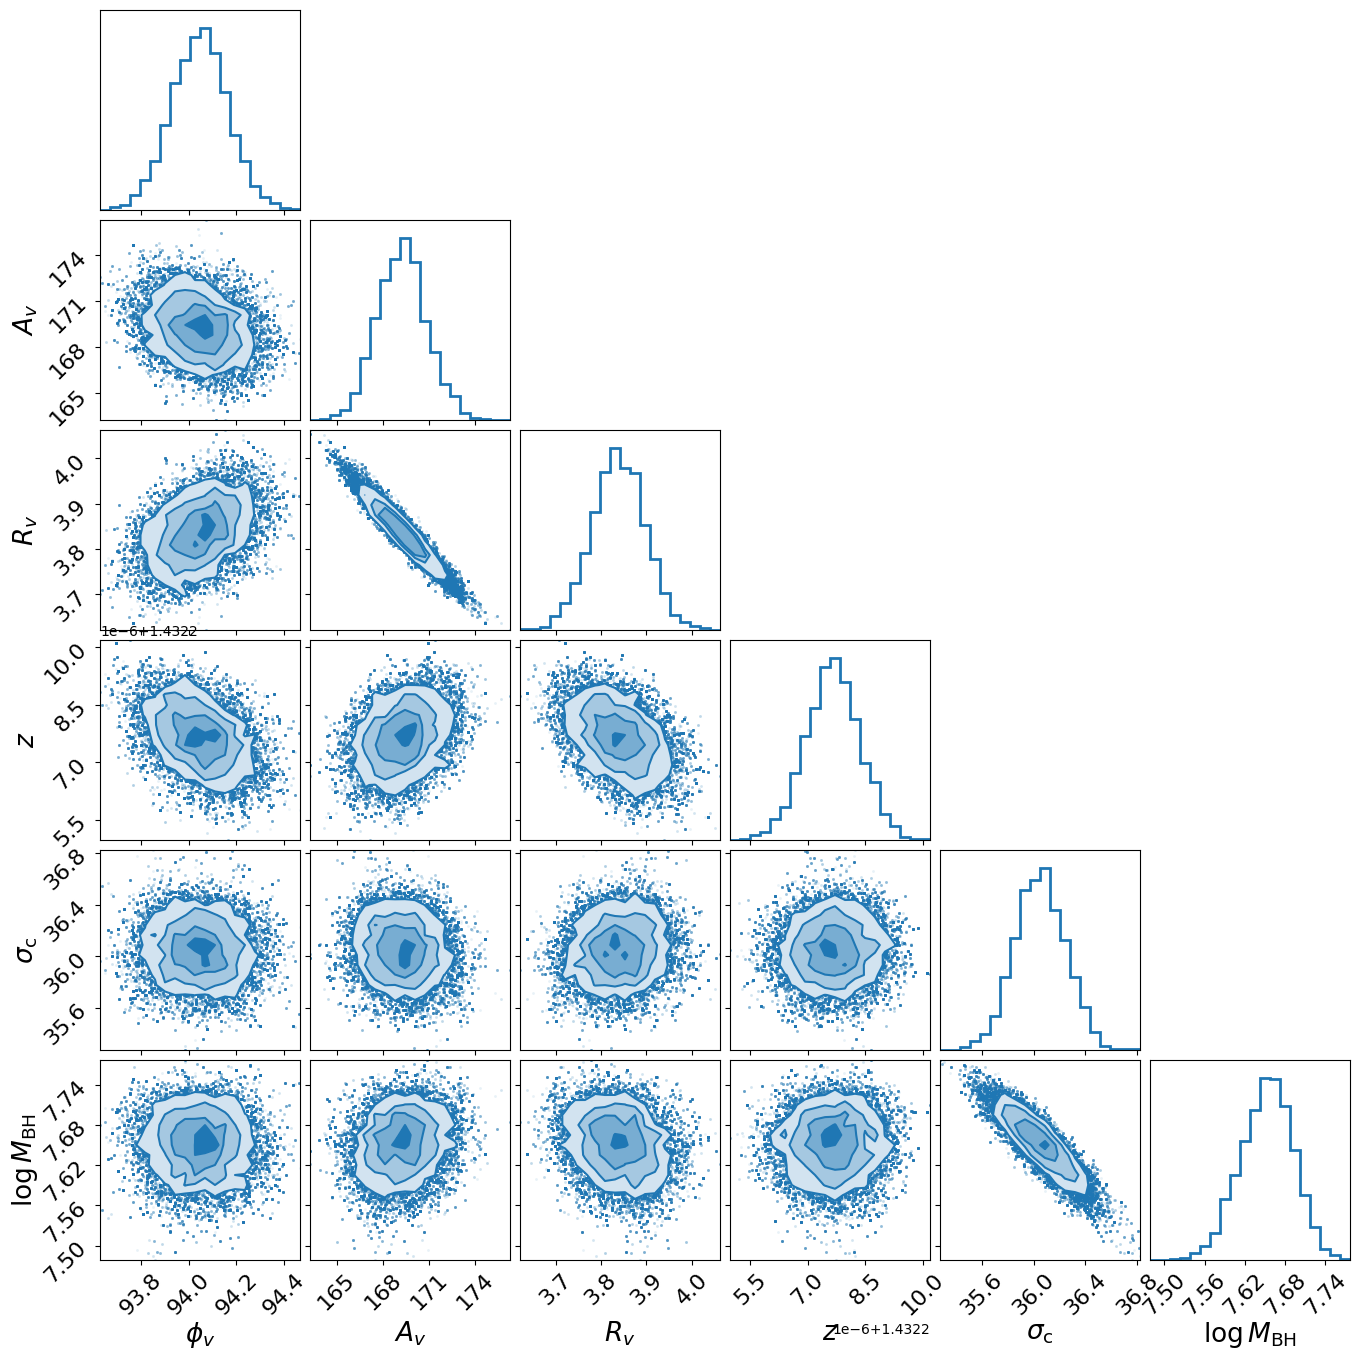

In [42]:
iful_v_samples = np.column_stack([iful_v_chains[p] for p in param_names])

fig = corner.corner(
    iful_v_samples,
    labels=param_names,
    color="#1f77b4",          # Sleek Blue
    plot_datapoints=True,
    plot_density=True,
    fill_contours=True,
    show_titles=False,
    hist_kwargs={"linewidth": 2},
    label_kwargs={"fontsize": 19}
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=16)

plt.show()

In [44]:
table_lines = [
    "| Parameter | IFUL |",
    "| :--- | :--- |"
]
for p in param_names:
    row_str = f"| {p} "
    for name, chain in [("IFUL", iful_v_chains)]:
        mean_val = np.mean(chain[p])
        std_val = np.std(chain[p])
        row_str += f"| {mean_val:.7f} ± {std_val:.7f} "
    row_str += "|"
    table_lines.append(row_str)

display(Markdown("\n".join(table_lines)))

| Parameter | IFUL |
| :--- | :--- |
| $\phi_{v}$ | 94.0442099 ± 0.1190623 |
| $A_{v}$ | 169.2321054 ± 1.5988306 |
| $R_{v}$ | 3.8379875 ± 0.0586025 |
| $z$ | 1.4322076 ± 0.0000007 |
| $\sigma_{\rm c}$ | 36.0484433 ± 0.1956933 |
| $\log M_{\rm BH}$ | 7.6522789 ± 0.0394265 |

In [ ]:
theta_name = r"$\theta_{\rm E}~\sigma_{\rm stat}$"
gamma_name = r'$\gamma~\sigma_{\rm stat}$'

data = {theta_name: [], gamma_name: []}

df = pd.DataFrame(data)
df